# Notebook 01: EDA and Preprocessing
**Dataset:** UCF-Crime pre-extracted 64x64 PNG frames (14 classes, Train + Test splits)
**Goal:** Understand class distribution, visualise frames, build 8-frame clips, save `.npy` arrays.

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.config import (
    DATA_DIR, PLOTS_DIR, RESULTS_DIR, SEED, CLASSES, CLASS_MAP,
    CLASS_TO_IDX, MAX_FRAMES, CLIP_LEN, TRAIN_STRIDE
)
from src.eda import run_all_eda
from src.dataset import (
    discover_videos, make_video_splits, build_clips
)

import random
random.seed(SEED)
np.random.seed(SEED)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Dataset root : {DATA_DIR}')
print(f'Selected classes: {CLASSES}')

Dataset root : /home/mjl/softwarica/ANN/data/dataset
Selected classes: ['Normal', 'Fighting', 'Robbery', 'Arson', 'Burglary']


## 1. EDA Visualisations
Runs all six plots: frame counts, capping, sample frames, brightness, video counts, clip estimates.

Running EDA visualisations...
All EDA plots saved to /home/mjl/softwarica/ANN/outputs/plots


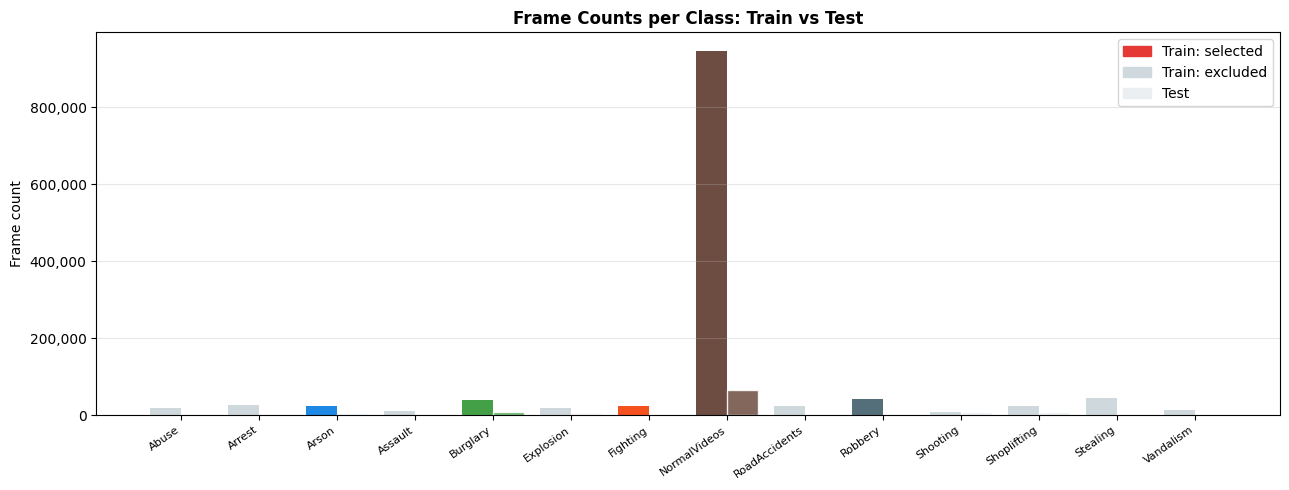

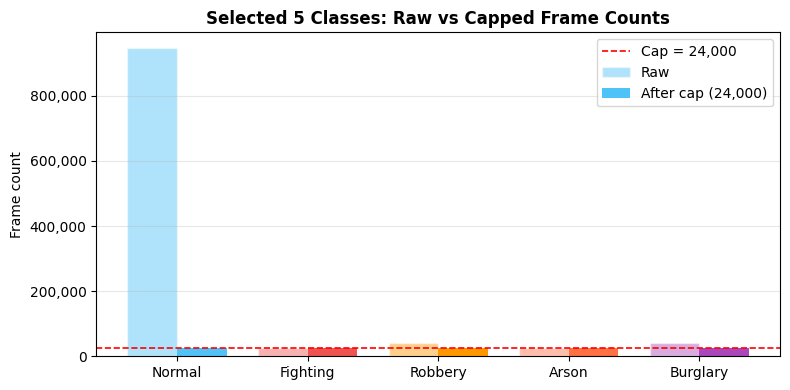

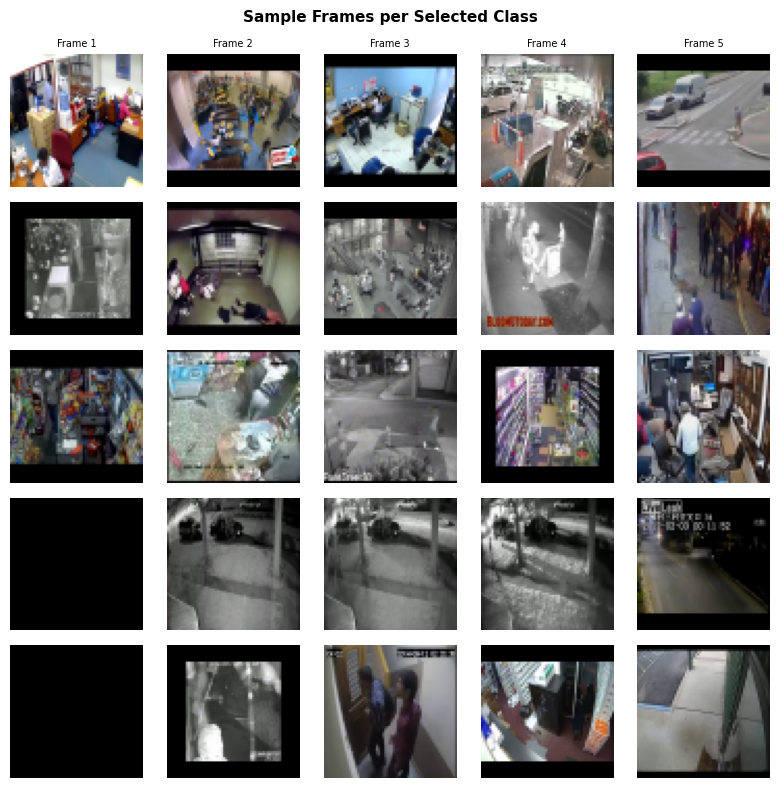

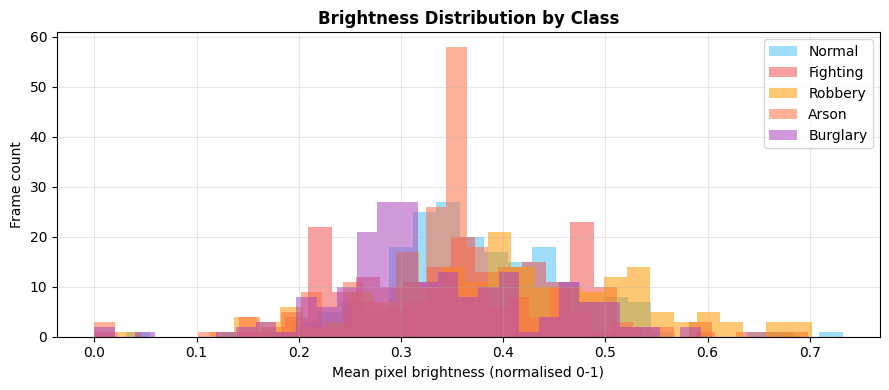

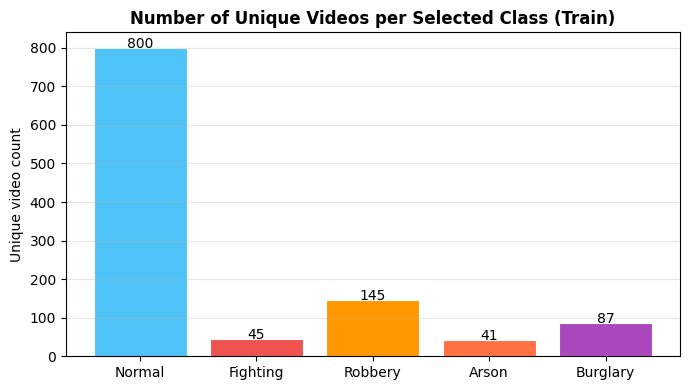

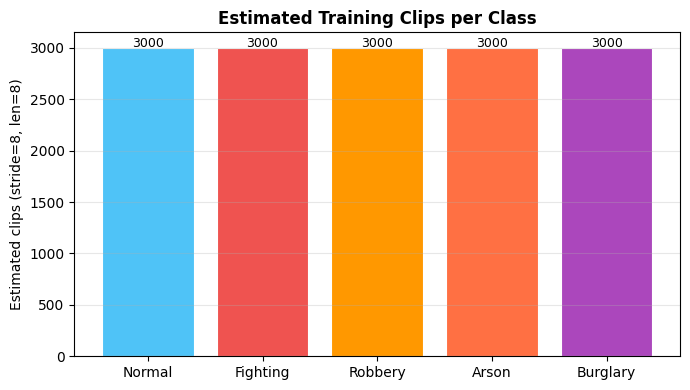

In [2]:
train_counts, test_counts = run_all_eda()
plt.show()

## 2. Dataset Summary Table

In [3]:
print(f"\n{'Class':<16} {'Train frames':>13} {'Test frames':>12} {'Train videos (est)':>18}")
print('-' * 63)
for folder, label in CLASS_MAP.items():
    tr = train_counts.get(folder, 0)
    te = test_counts.get(folder, 0)
    clips_est = max(0, (min(tr, MAX_FRAMES) - CLIP_LEN) // TRAIN_STRIDE + 1)
    print(f'  {label:<14} {tr:>13,} {te:>12,} {clips_est:>18,}')


Class             Train frames  Test frames Train videos (est)
---------------------------------------------------------------
  Normal               947,768       64,952              3,000
  Fighting              24,684        1,231              3,000
  Robbery               41,493          835              3,000
  Arson                 24,421        2,793              3,000
  Burglary              39,504        7,657              3,000


## 3. Discover Videos

In [4]:
print('Discovering videos...')
video_dict_train = discover_videos(DATA_DIR, split='Train')
video_dict_test  = discover_videos(DATA_DIR, split='Test')

for label, vids in video_dict_train.items():
    print(f'  Train  {label:<12}: {len(vids):>4} videos')
for label, vids in video_dict_test.items():
    print(f'  Test   {label:<12}: {len(vids):>4} videos')

Discovering videos...
  Train  Normal      :  800 videos
  Train  Fighting    :   45 videos
  Train  Robbery     :  145 videos
  Train  Arson       :   41 videos
  Train  Burglary    :   87 videos
  Test   Normal      :  150 videos
  Test   Fighting    :    5 videos
  Test   Robbery     :    5 videos
  Test   Arson       :    9 videos
  Test   Burglary    :   13 videos


## 4. Video-Level Train / Val / Test Split
Split by **video ID** — no clips from the same source video appear in more than one partition.
The UCF-Crime Test folder provides a fully separate set of source videos for evaluation.

In [5]:
splits, normal_train_vids = make_video_splits(video_dict_train, video_dict_test)

print('\nSplit sizes:')
for name, (paths, y) in splits.items():
    dist = dict(zip(CLASSES, np.bincount(y, minlength=len(CLASSES))))
    print(f'  {name:<6} {len(paths):>5} clips  {dist}')

normal_paths = build_clips(normal_train_vids, TRAIN_STRIDE, max_frames=MAX_FRAMES)
print(f'\nNormal pre-train clips (capped): {len(normal_paths):,}')

  Normal       train=3000 clips (680 vids)  val=3000 clips (120 vids)
  Fighting     train=2766 clips (38 vids)  val= 299 clips (7 vids)
  Robbery      train=3000 clips (123 vids)  val=1030 clips (22 vids)
  Arson        train=2892 clips (35 vids)  val= 145 clips (6 vids)
  Burglary     train=3000 clips (74 vids)  val=1198 clips (13 vids)

Test (separate Test folder):
  Normal       test=3000 clips
  Fighting     test= 300 clips
  Robbery      test= 202 clips
  Arson        test= 687 clips
  Burglary     test=1897 clips

Split sizes:
  train  14658 clips  {'Normal': np.int64(3000), 'Fighting': np.int64(2766), 'Robbery': np.int64(3000), 'Arson': np.int64(2892), 'Burglary': np.int64(3000)}
  val     5672 clips  {'Normal': np.int64(3000), 'Fighting': np.int64(299), 'Robbery': np.int64(1030), 'Arson': np.int64(145), 'Burglary': np.int64(1198)}
  test    6086 clips  {'Normal': np.int64(3000), 'Fighting': np.int64(300), 'Robbery': np.int64(202), 'Arson': np.int64(687), 'Burglary': np.int64(1

## 5. Save `.npy` Arrays
Run once from the terminal — subsequent notebooks load directly from `.npy`.
```bash
python scripts/save_npy.py
```
The script writes arrays in 500-clip chunks using `np.memmap` so peak RAM stays under 200 MB regardless of dataset size.

In [6]:
# Verify saved files exist
import os
expected = ['X_train.npy','y_train.npy','X_val.npy','y_val.npy',
            'X_test.npy','y_test.npy','X_normal.npy']
for fname in expected:
    path = RESULTS_DIR / fname
    size = os.path.getsize(path) / 1e9 if path.exists() else None
    status = f'{size:.2f} GB' if size else 'MISSING'
    print(f'  {fname:<20} {status}')

  X_train.npy          5.76 GB
  y_train.npy          0.00 GB
  X_val.npy            2.23 GB
  y_val.npy            0.00 GB
  X_test.npy           2.39 GB
  y_test.npy           0.00 GB
  X_normal.npy         1.18 GB
